In [65]:
import pandas as pd
import os
# # Path to the CSV file in the ESC-50 dataset
# Path = '/Users/bchhaglani/Desktop/Audio_privacy/ESC-50-master/'
# csv_path = Path + 'meta/esc50.csv'

# # Load the CSV into a DataFrame
# df = pd.read_csv(csv_path)
# audio_path_prefix = Path+'/audio/'


# df = df[['filename', 'category']]

# print(df.head())


# def main():
ds_path = "/Users/bchhaglani/Desktop/Audio_Privacy/AudioWAV/"  # Update with your CREMA-D audio directory

# Create metadata for CREMA-D using the provided snippet
crema_directory_list = os.listdir(ds_path)

file_emotion = []
file_path = []

for file in crema_directory_list:
    if file.endswith(".wav"):  # Ensure only WAV files are processed
        # storing file paths
        file_path.append(os.path.join(ds_path, file))
        # storing file emotions
        part = file.split('_')
        if part[2] == 'SAD':
            file_emotion.append('sad')
        elif part[2] == 'ANG':
            file_emotion.append('angry')
        elif part[2] == 'DIS':
            file_emotion.append('disgust')
        elif part[2] == 'FEA':
            file_emotion.append('fear')
        elif part[2] == 'HAP':
            file_emotion.append('happy')
        elif part[2] == 'NEU':
            file_emotion.append('neutral')
        else:
            file_emotion.append('Unknown')

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files
path_df = pd.DataFrame(file_path, columns=['Path'])
data = pd.concat([emotion_df, path_df], axis=1)
data

,Emotions,Path
0,angry,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
1,angry,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
2,neutral,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
3,neutral,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
4,disgust,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
...,...,...
7437,angry,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
7438,angry,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
7439,angry,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...
7440,angry,/Users/bchhaglani/Desktop/Audio_Privacy/AudioW...


In [66]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Filter for happy and sad emotions
data = data[
    (data['Emotions'].isin(['happy', 'sad', 'angry']))
]

# Rename columns to match expected 'filename' and 'emotion'
data = data.rename(columns={'Path': 'filename', 'Emotions': 'emotion'})

# Select up to 2,000 files, as in the original code
data = data[['filename', 'emotion']].dropna().head(2000)
data['filename'] = data['filename'].apply(os.path.basename)

data

,filename,emotion
0,1022_ITS_ANG_XX.wav,angry
1,1037_ITS_ANG_XX.wav,angry
6,1078_IWL_SAD_XX.wav,sad
8,1039_IEO_SAD_MD.wav,sad
9,1008_TAI_HAP_XX.wav,happy
...,...,...
3899,1022_IOM_ANG_XX.wav,angry
3904,1056_MTI_HAP_XX.wav,happy
3905,1043_MTI_HAP_XX.wav,happy
3908,1003_IEO_SAD_HI.wav,sad


In [67]:
# # df = pd.read_csv(csv_path)
# data['Emotions'].unique()
# # df['target'].unique()
# # df[['target', 'category']]

In [68]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score



import librosa
import numpy as np



import numpy as np
import pandas as pd
import librosa
from scipy.stats import kurtosis, skew

import librosa
import numpy as np
import pandas as pd

# def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
#     # Load audio file
#     y, sr = librosa.load(file_path, sr=None)
    
#     # Calculate window and hop lengths in samples
#     window_length = int(window_size * sr)
#     hop_length = int(hop_size * sr)
    
#     # Initialize list to store extracted features
#     all_features = []
#     print ("Processing...", file_path)
    
#     # Sliding window over the audio signal
#     for start in range(0, len(y) - window_length + 1, hop_length):
        
#         # Get the current window segment
#         window_segment = y[start:start + window_length]
        
#         # Initialize dictionary to store features for the current window
#         features = {}

#         # Time-Domain Features
#         features['Amplitude Envelope'] = np.max(np.abs(window_segment))
#         features['Root Mean Square (RMS)'] = librosa.feature.rms(y=window_segment).mean()
#         features['Zero Crossing Rate (ZCR)'] = librosa.feature.zero_crossing_rate(window_segment).mean()
#         features['Peak Value'] = np.max(np.abs(window_segment))
#         features['Short-Term Energy (STE)'] = np.sum(window_segment ** 2) / len(window_segment)

#         total_energy = np.sum(window_segment ** 2)
#         features['Temporal Centroid'] = (
#             np.sum(np.arange(len(window_segment)) * window_segment ** 2) / total_energy
#             if total_energy > 0 else 0
#         )

#         # features['Temporal Centroid'] = np.sum(np.arange(len(window_segment)) * window_segment ** 2) / np.sum(window_segment ** 2)
#         features['Attack Time'] = np.argmax(window_segment ** 2) / sr
#         features['Decay Time'] = (len(window_segment) - np.argmax(window_segment ** 2)) / sr
#         features['Release Time (ADSR)'] = np.sum(window_segment ** 2 < 0.01 * np.max(window_segment ** 2)) / sr

#         # Spectral Features
#         features['Spectral Centroid'] = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
#         features['Spectral Flatness'] = librosa.feature.spectral_flatness(y=window_segment).mean()
#         features['Spectral Contrast'] = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
#         features['Spectral Spread'] = np.mean(librosa.feature.spectral_bandwidth(y=window_segment, sr=sr))

#         power_spectrum = np.abs(np.fft.rfft(window_segment)) ** 2
#         normalized_ps = power_spectrum / np.sum(power_spectrum + 1e-12)
#         features['Spectral Entropy'] = -np.sum(normalized_ps * np.log2(normalized_ps + 1e-12))

#         # features['Spectral Entropy'] = -(np.sum(window_segment ** 2 * np.log(window_segment ** 2 + 1e-12)))
#         features['Chroma Features'] = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()
#         spectral_flux = np.mean(librosa.onset.onset_strength(y=window_segment, sr=sr))
#         features['Spectral Flux'] = spectral_flux

#         # Perceptual Features
#         features['Loudness'] = librosa.feature.rms(y=window_segment).mean()
#         features['Sharpness'] = np.mean(librosa.feature.spectral_bandwidth(y=window_segment, sr=sr))
#         features['Roughness'] = librosa.feature.spectral_flatness(y=window_segment).mean()
#         features['Timbre'] = librosa.feature.mfcc(y=window_segment, sr=sr).mean()
#         features['Reverberation'] = librosa.effects.harmonic(window_segment).mean()
#         features['Bark Coefficients'] = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()

#         # Statistical Features
#         features['Mean'] = np.mean(window_segment)
#         features['Variance'] = np.var(window_segment)
#         features['Standard Deviation'] = np.std(window_segment)
#         features['Kurtosis'] = kurtosis(window_segment)
#         features['Skewness'] = skew(window_segment)
#         # features['Entropy'] = -(np.sum(window_segment ** 2 * np.log(window_segment ** 2 + 1e-12)))

#         # Voice-Specific Features
#         pitches, magnitudes = librosa.piptrack(y=window_segment, sr=sr)
#         features['Pitch'] = np.mean(pitches[pitches > 0]) if np.any(pitches > 0) else 0
#         harmonic, percussive = librosa.effects.hpss(window_segment)
#         features['HNR'] = np.mean(harmonic ** 2) / (np.mean(percussive ** 2) + 1e-12)

#         # features['Harmonics-to-Noise Ratio (HNR)'] = librosa.effects.harmonic(window_segment).mean()


#         # Time-Frequency Features or # High-Level Features
#         # Group delay
#         # D = librosa.stft(window_segment)
#         # group_delay = librosa.phase_vocoder(D, rate=2.0)
#         # y_fast  = librosa.istft(group_delay, hop_length=512)
#         # group_delay = np.mean(y_fast)
# #         group_delay = np.mean(np.diff(librosa.phase_vocoder(window_segment, rate=1.0, hop_length=512).flatten()))
#         wavelet_coeff = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))  # Wavelet approximation
#         # features['Group Delay'] = group_delay
#         features['Wavelet Features'] = wavelet_coeff        
#         # features['Group Delay'] = np.mean(np.gradient(np.unwrap(np.angle(librosa.stft(window_segment)))))
#         phase_angle = np.angle(librosa.stft(window_segment))
#         group_delay = -np.gradient(phase_angle, axis=0)
#         features['Group Delay'] = np.mean(group_delay)


#         # Derived Features
#         stft = np.abs(librosa.stft(window_segment))
#         freqs = librosa.fft_frequencies(sr=sr)
        
#         # Define frequency bands
#         low_band = stft[freqs < 250, :]  # Frequencies below 250 Hz
#         mid_band = stft[(freqs >= 250) & (freqs < 2000), :]  # Frequencies between 250 Hz and 2 kHz
#         high_band = stft[freqs >= 2000, :]  # Frequencies above 2 kHz
        
#         features['Low Band Energy'] = np.sum(low_band)
#         features['Mid Band Energy'] = np.sum(mid_band)
#         features['High Band Energy'] = np.sum(high_band)

        
#         # Add window index and label
#         features['Window Index'] = start // hop_length
#         features['Label'] = label

#         # Append the features of the current window to the list
#         all_features.append(features)

#     # Convert list of features to a DataFrame
#     df = pd.DataFrame(all_features)
#    return df

feature_groups = {
    'Time Domain Features': [
        'Amplitude Envelope', 'RMS', 'Zero Crossing Rate (ZCR)', 
        'Short-Term Energy (STE)', 'Temporal Centroid', 
        'Envelop Modulation rate', 'Silence Ratio'
    ],
    'Spectral Features': [
        'Spectral Centroid', 'Spectral Flatness', 'Spectral Contrast', 
        'Spectral Spread', 'Spectral Entropy', 'Chroma Features', 
        'Spectral Irregularity',
    ],
    'Statistical Features': [
        'Mean', 'Variance', 'Standard Deviation', 'Kurtosis', 'Skewness', 'Entropy'
    ],
    'Perceptual Features': [
        'Sharpness', 'Timbre', 'Reverberation'
    ],
    'Voice-Specific Features': [
        'Pitch', 'HNR', 'Jitter', 'Shimmer'
    ],
    'High-Level Features (Time-Frequency)': [
        'Group Delay', 'Wavelet Features', 'Temporal Spectral Slope'
    ],
    'Derived Features': [
       'Transient-to-Sustained Ratio', 'Tonality Index', 'Spectral Roughness', 'Spectral Texture Coefficients', 'Directional Spectral Features','Low Band Energy', 'Mid Band Energy', 'High Band Energy', 'LH1000', 
    ]
}


# Function to parse the CSV file
def parse_csv(file_path):
    """Parses CSV to extract filenames and labels."""
    df = pd.read_csv(file_path)
    return df

    
def compute_sharpness(y, sr):
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    rms = librosa.feature.rms(y=y).mean()
    sharpness = spectral_centroid / (rms + 1e-12)
    return sharpness



# Function for Spectral Roughness
def compute_spectral_roughness(y, sr):
    stft = np.abs(librosa.stft(y))
    roughness = np.sum(np.abs(np.diff(stft, axis=0)), axis=0)
    return np.mean(roughness)

# Function for Tonality Index
def compute_tonality_index(y, sr):
    stft = np.abs(librosa.stft(y))
    harmonic_energy = np.sum(stft[stft > np.mean(stft)])
    noise_energy = np.sum(stft[stft <= np.mean(stft)])
    return harmonic_energy / (noise_energy + 1e-12)

# Function for Spectral Texture Coefficients
def compute_spectral_texture(y, wavelet='db4', level=4):
    import pywt
    coeffs = pywt.wavedec(y, wavelet, level=level)
    texture_features = [np.std(c) for c in coeffs]
    return np.mean(texture_features)

# Function for Transient-to-Sustained Ratio
def compute_transient_sustained_ratio(y, sr, threshold=0.01):
    energy = librosa.feature.rms(y=y)
    transient_energy = np.sum(energy[energy > threshold])
    sustained_energy = np.sum(energy[energy <= threshold])
    return transient_energy / (sustained_energy + 1e-12)

# Function for Directional Spectral Features
def compute_directional_spectral_features(y, sr):
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    delta_centroid = librosa.feature.delta(spectral_centroid)
    return np.mean(delta_centroid)

def estimate_reverberation_rt60(y, sr):
    ir = librosa.effects.harmonic(y)
    edc = np.cumsum(ir[::-1] ** 2)[::-1]
    edc_db = 10 * np.log10(edc / np.max(edc))

    # Find RT60 points
    rt60_start = np.where(edc_db <= -5)[0]
    rt60_end = np.where(edc_db <= -60)[0]

    if len(rt60_start) == 0 or len(rt60_end) == 0:
        # Return 0 if RT60 points are not found
        return 0.0

    rt60 = (rt60_end[0] - rt60_start[0]) / sr
    return rt60


def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)
    
    # Initialize list to store extracted features
    all_features = []

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        # Get the current window segment
        window_segment = y[start:start + window_length]
        
        # Initialize dictionary to store features for the current window
        features = {}

        # Time Domain Features
        threshold = 0.01
        features['Amplitude Envelope'] = np.max(np.abs(window_segment))
        features['RMS'] = librosa.feature.rms(y=window_segment).mean()
        features['Zero Crossing Rate (ZCR)'] = librosa.feature.zero_crossing_rate(window_segment).mean()
        features['Peak Value'] = np.max(np.abs(window_segment))
        features['Short-Term Energy (STE)'] = np.mean(window_segment ** 2)
        total_energy = np.sum(window_segment ** 2)
        features['Temporal Centroid'] = (
            np.sum(np.arange(len(window_segment)) * window_segment ** 2) / total_energy
            if total_energy > 0 else 0
        )
        envelope = np.abs(librosa.onset.onset_strength(y=window_segment, sr=sr))
        modulation_rate = np.mean(np.abs(np.diff(envelope)))
        features['Envelop Modulation rate'] = modulation_rate
        silence_to_sound_ratio = np.sum(np.abs(window_segment) < threshold) / len(window_segment)
        features['Silence Ratio'] = silence_to_sound_ratio



        # Spectral Features
        features['Spectral Centroid'] = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
        features['Spectral Flatness'] = librosa.feature.spectral_flatness(y=window_segment).mean()
        features['Spectral Contrast'] = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
        features['Spectral Spread'] = np.mean(librosa.feature.spectral_bandwidth(y=window_segment, sr=sr))
        power_spectrum = np.abs(np.fft.rfft(window_segment)) ** 2
        normalized_ps = power_spectrum / np.sum(power_spectrum + 1e-12)
        features['Spectral Entropy'] = -np.sum(normalized_ps * np.log2(normalized_ps + 1e-12))
        features['Chroma Features'] = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()
        stft = librosa.stft(window_segment)
        spectral_irregularity = np.sum(np.abs(np.diff(np.abs(stft), axis=0)))
        features['Spectral Irregularity'] = spectral_irregularity
        spectral_kurtosis = kurtosis(np.abs(stft), axis=0).mean()
        spectral_skewness = skew(np.abs(stft), axis=0).mean()
        features['Spectral Skewness'] = spectral_skewness
        features['Spectral Kurtosis'] = spectral_kurtosis



        # Statistical Features
        features['Mean'] = np.mean(window_segment)
        features['Variance'] = np.var(window_segment)
        features['Standard Deviation'] = np.std(window_segment)
        features['Kurtosis'] = kurtosis(window_segment)
        features['Skewness'] = skew(window_segment)
        features['Entropy'] = -np.sum((window_segment ** 2) * np.log2(window_segment ** 2 + 1e-12))

        # Perceptual Features
        features['Sharpness'] = np.mean(librosa.feature.spectral_bandwidth(y=window_segment, sr=sr))
        features['Timbre'] = librosa.feature.mfcc(y=window_segment, sr=sr).mean()
        features['Sharpness'] = compute_sharpness(window_segment, sr)
        features['Reverberation'] = estimate_reverberation_rt60(window_segment, sr)


        # Voice-Specific Features
        pitches, magnitudes = librosa.piptrack(y=window_segment, sr=sr)
        features['Pitch'] = np.mean(pitches[pitches > 0]) if np.any(pitches > 0) else 0
        harmonic, percussive = librosa.effects.hpss(window_segment)
        features['HNR'] = np.mean(harmonic ** 2) / (np.mean(percussive ** 2) + 1e-12)
        jitter = np.var(np.diff(window_segment))  # Voice quality jitter estimation
        shimmer = np.mean(np.abs(np.diff(window_segment)))  # Voice quality shimmer estimation
        features['Jitter'] = jitter
        features['Shimmer'] = shimmer

        # High-Level Features (Time-Frequency)
        phase_angle = np.angle(librosa.stft(window_segment))
        group_delay = -np.gradient(phase_angle, axis=0)
        features['Group Delay'] = np.mean(group_delay)
        wavelet_coeff = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))  # Wavelet approximation
        features['Wavelet Features'] = wavelet_coeff
        spectral_centroids = librosa.feature.spectral_centroid(y=window_segment, sr=sr)
        temporal_spectral_slope = np.mean(np.diff(spectral_centroids))
        features['Temporal Spectral Slope'] = temporal_spectral_slope
 



        # Derived Features
        features['Transient-to-Sustained Ratio'] = compute_transient_sustained_ratio(window_segment, sr)
        features['Tonality Index'] = compute_tonality_index(window_segment, sr)
        features['Spectral Roughness'] = compute_spectral_roughness(window_segment, sr)
        features['Spectral Texture Coefficients'] = compute_spectral_texture(window_segment)
        features['Directional Spectral Features'] = compute_directional_spectral_features(window_segment, sr)
        # Derived Features
        stft = np.abs(librosa.stft(window_segment))
        freqs = librosa.fft_frequencies(sr=sr)
        low_band = stft[freqs < 500, :]
        mid_band = stft[(freqs >= 500) & (freqs < 2000), :]
        high_band = stft[freqs >= 2000, :]
        features['Low Band Energy'] = np.sum(low_band)
        features['Mid Band Energy'] = np.sum(mid_band)
        features['High Band Energy'] = np.sum(high_band)
        features['LH1000'] = np.sum(low_band) / (np.sum(high_band) + 1e-12)

        # # Derived Features
        # stft = np.abs(librosa.stft(window_segment))
        # freqs = librosa.fft_frequencies(sr=sr)
        # low_band = stft[freqs < 500, :]
        # mid_band = stft[(freqs >= 500) & (freqs < 2000), :]
        # high_band = stft[freqs >= 2000, :]
        # features['Low Band Energy'] = np.sum(low_band)
        # features['Mid Band Energy'] = np.sum(mid_band)
        # features['High Band Energy'] = np.sum(high_band)
        # features['LH1000'] = np.sum(low_band) / (np.sum(high_band) + 1e-12)
        # # low_energy = np.sum(stft[freqs < 500, :])
        # # mid_energy = np.sum(stft[(freqs >= 500) & (freqs < 2000), :])
        # # high_energy = np.sum(stft[freqs >= 2000, :])
        # # low_to_total_ratio = low_energy / (low_energy + mid_energy + high_energy + 1e-12)
        # # features['LH1000'] = np.sum(low_band) / (np.sum(high_band) + 1e-12)


        # Add window index and label
        features['Window Index'] = start // hop_length
        features['Label'] = label

        # Append the features of the current window to the list
        all_features.append(features)

    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)
    return df




# # Extract features for each audio file
audio_path_prefix = ds_path
features_list = pd.DataFrame()
labels_list = []
for _, row in data.iterrows():
    
    features = extract_features_with_sliding_window(audio_path_prefix + row['filename'], row['emotion'])
    features_list = features_list._append(features)
    
#     features_list.extend(features)
#     labels_list.extend([row['target']] * len(features))
#     print(len(features_list))



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/librosa/util/decorators.py:88: UserWarning: n_fft=256 is too small for input signal of length=250
  return f(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/librosa/util/decorators.py:88: UserWarning: n_fft=256 is too small for input signal of length=125
  return f(*args, **kwargs)


KeyboardInterrupt: 

In [131]:
# features_list['Wavelet Features']
# X = np.load('long_features.npy',allow_pickle=True)
# y = np.load('long_features_labels.npy')

# Peak Value	0.060914
# 0	Amplitude Envelope	0.052383
# 28	Jitter	0.051964
# 35	Spectral Roughness	0.032272
# 36	Spectral Texture Coefficients	

features_list2 = features_list.drop(['Peak Value', 'Amplitude Envelope', 'Jitter', 'Spectral Roughness', 'Spectral Texture Coefficients' ], axis=1)


In [132]:
features_list3 = features_list.dropna()
features_list3 = features_list2.dropna()

In [133]:
X = np.array(features_list3.iloc[:,:-1])
y = np.array(features_list3.iloc[:, -1])

In [134]:
features_list3

,RMS,Zero Crossing Rate (ZCR),Short-Term Energy (STE),Temporal Centroid,Envelop Modulation rate,Silence Ratio,Spectral Centroid,Spectral Flatness,Spectral Contrast,Spectral Spread,...,Temporal Spectral Slope,Transient-to-Sustained Ratio,Tonality Index,Directional Spectral Features,Low Band Energy,Mid Band Energy,High Band Energy,LH1000,Window Index,Label
0,0.027208,0.097473,0.001711,6641.276285,2.273188,0.635375,1830.137800,0.034334,17.295777,1843.656703,...,-83.309734,5.631873e+00,5.412650,-61.337955,1440.133057,996.903320,2333.214111,0.617231,0,angry
1,0.116772,0.209991,0.022184,4290.093081,2.367373,0.181125,2514.229561,0.061196,19.021381,1810.492262,...,136.489192,1.868358e+12,4.095648,211.914736,3299.694824,5742.225586,9533.904297,0.346101,1,angry
2,0.119488,0.247742,0.022750,5945.564447,1.666274,0.088625,2669.519761,0.055737,19.315105,1826.736638,...,44.897483,1.911808e+12,3.549479,-107.693427,5285.819824,4609.705078,14978.423828,0.352896,2,angry
3,0.137699,0.146637,0.034298,3178.855025,1.474046,0.182125,2410.460117,0.035150,18.515255,1945.779707,...,-80.387541,2.203189e+12,4.182197,43.097556,3948.752686,6561.524414,13087.214844,0.301726,3,angry
4,0.102983,0.110138,0.021310,6578.238160,1.161976,0.250625,1929.458567,0.030712,18.821898,1803.627629,...,-215.037481,1.647720e+12,4.600224,-216.921683,3597.434570,5762.355469,3113.275391,1.155514,4,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,0.022328,0.060883,0.000763,5764.191428,1.313126,0.496125,1269.268454,0.006257,17.771603,1725.026251,...,-1.408875,8.254644e+00,6.124882,-21.960855,1085.802856,1244.596924,429.079010,2.530543,1,angry
2,0.032553,0.069855,0.001255,3550.256028,1.097372,0.287000,1150.010716,0.004382,19.275163,1280.232386,...,0.981980,5.208554e+11,5.762472,3.683961,1357.808105,2275.262207,594.927979,2.282307,2,angry
3,0.023272,0.088379,0.000811,3269.006698,1.048987,0.513625,1291.709368,0.009273,17.457499,1388.326375,...,25.341713,9.402181e+00,6.377607,11.639578,781.789062,2277.748047,557.958801,1.401159,3,angry
4,0.007177,0.052063,0.000059,3205.690478,0.644041,0.827750,1229.070895,0.010541,15.748986,1806.336718,...,-6.961589,0.000000e+00,3.941176,-14.768863,524.767944,329.300964,194.864594,2.692988,4,angry


In [135]:
# X_= []
# y_ = []
# for i in range(X.shape[0]):
#     if(len(X[i])!=42):
#         continue
#     X_.append(X[i])
#     y_.append(y[i])
        
# np.save('ESC_X_group.npy', X)
# np.save('ESC_y_group.npy', y)

In [136]:
# len(X_)

In [137]:
# X_

# X_ = np.array(X_)
# X_new = X_[:, :-26]

# X_

In [139]:
X.shape

(5498, 38)

In [140]:

# # X = np.reshape(X, [X.shape[0],49])
# y = np.array(labels_list)

X

# X_ = X[:,:-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [141]:
# arr = np.vstack([np.array(lst) for lst in X])
# arr.shape
# # X = np.reshape(X, (71603,42))

In [142]:
# X_ = []
# for i in X:
#     X_.append(i)

In [143]:
# X_ = np.array(X_)

In [144]:
# np.save('long_features.npy', X)
# np.save('long_features_labels.npy', y)


In [145]:
X_train.shape# X

(4398, 38)

In [146]:
# np.any(np.isnan(X_test))


In [147]:



X_test = X_test.astype(np.float)
X_train = X_train.astype(np.float)

X_test = np.nan_to_num(X_test)
X_train = np.nan_to_num(X_train)

AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [148]:
X_train.shape, X_train[0]

((4398, 38),
 array([ 9.80316699e-02,  1.60064697e-01,  1.37325684e-02,  5.75059380e+03,
         2.25539231e+00,  1.75000000e-01,  2.41379617e+03,  3.68277356e-02,
         1.95582348e+01,  1.78163988e+03,  8.51144644e+00,  2.46154979e-01,
         6.28293359e+03,  8.47003937e+00,  1.20705971e+02,  3.30162038e-05,
         1.37325684e-02,  1.17186040e-01,  4.04123444e+00,  2.58062531e-01,
         4.70927429e+02,  2.46226160e+04, -1.16639462e+01,  0.00000000e+00,
         1.99156128e+03,  3.68602714e-01,  4.81229126e-02,  6.92778907e-04,
         7.63631687e-02,  7.92938540e+01,  1.56850672e+12,  3.45576736e+00,
        -2.60514330e+01,  2.28329883e+03,  3.69475806e+03,  1.13593516e+04,
         2.01006089e-01,  4.00000000e+00]))

In [149]:
# Train a RandomForest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 65.91%


In [110]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, f1_score, recall_score, accuracy_score

cm = confusion_matrix(y_test, y_pred)



In [111]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n       angry       0.71      0.65      0.68       358\n       happy       0.56      0.49      0.53       351\n         sad       0.70      0.83      0.76       391\n\n    accuracy                           0.66      1100\n   macro avg       0.66      0.66      0.65      1100\nweighted avg       0.66      0.66      0.66      1100\n'

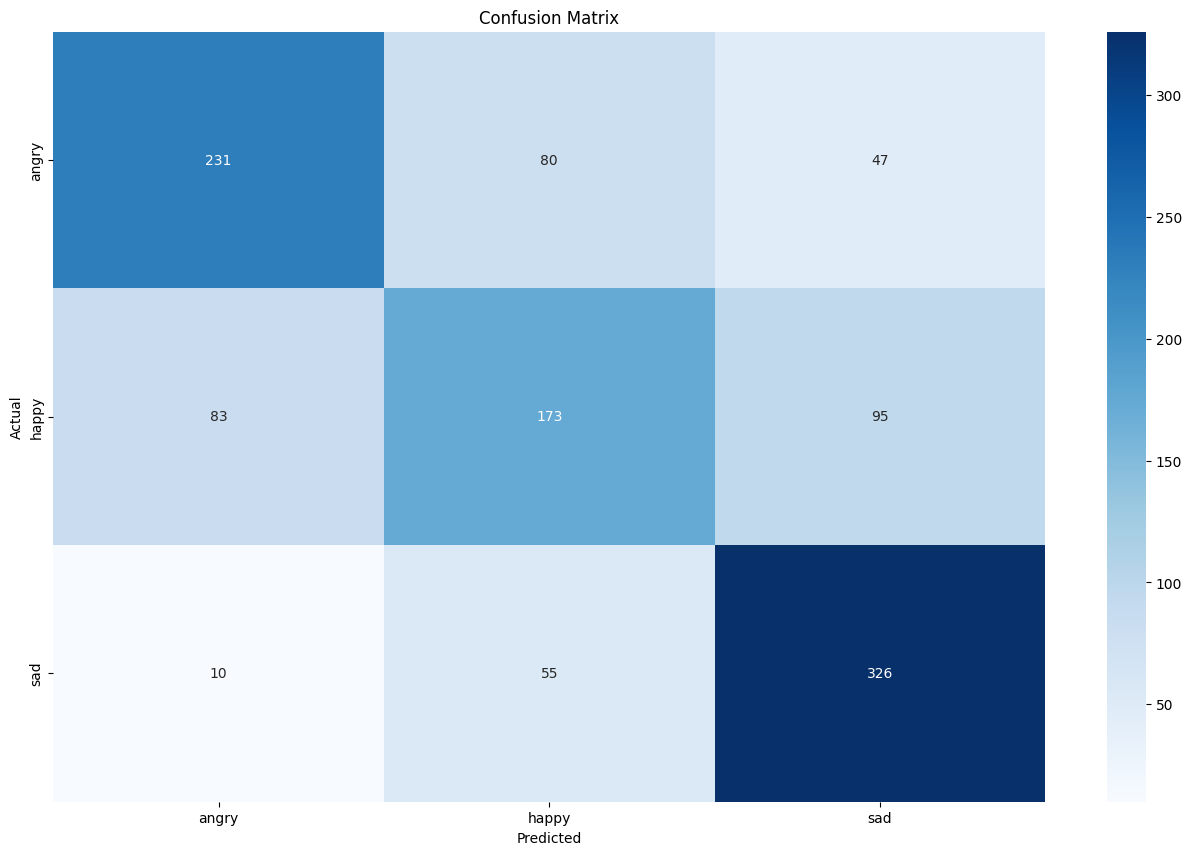

In [112]:
classes = np.unique(y_test)

import matplotlib.pyplot as plt
import seaborn as sns
# Plot confusion matrix using a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [113]:

# print('precision: {}'.format(precision_score(y_test, y_pred, average='macro')))
# print('recall: {}'.format(recall_score(y_test, y_pred)))
# print('fscore: {}'.format(accuracy_score(y_test, y_pred)))
# print('support: {}'.format(f1_score(y_test, y_pred)))


precision: [0.72839506 0.58227848 0.70869565]
recall: [0.65921788 0.52421652 0.83375959]
fscore: [0.69208211 0.55172414 0.76615746]
support: [358 351 391]


ValueError: x and y must have same first dimension, but have shapes (50,) and (3,)

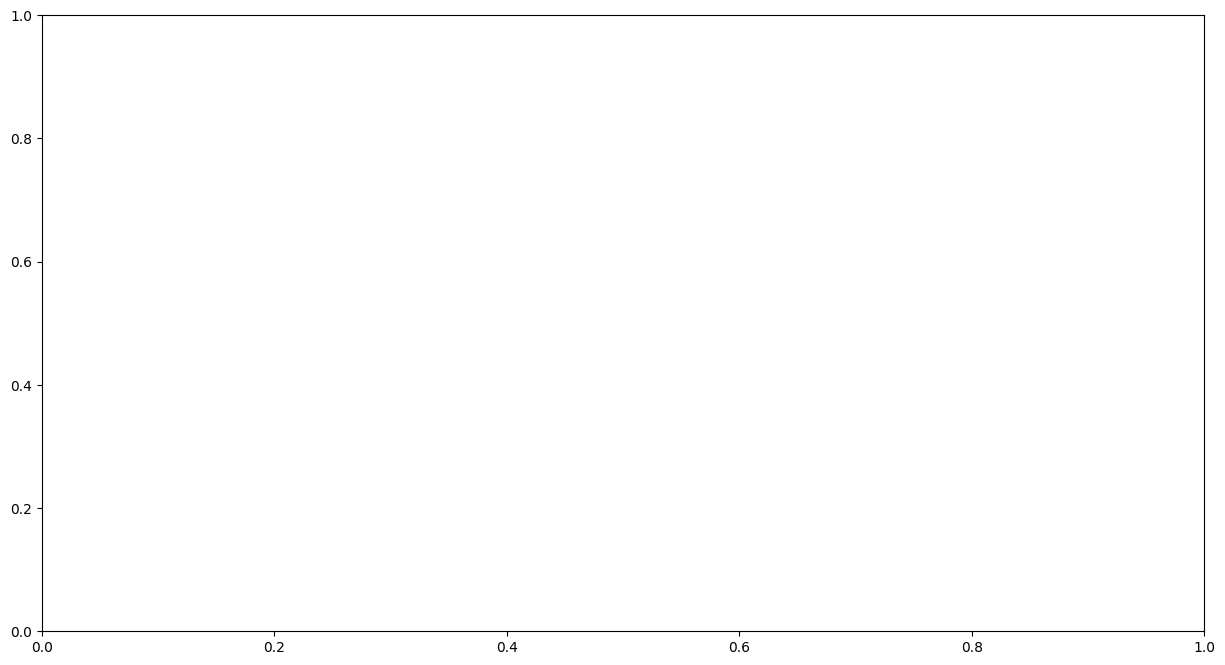

In [81]:
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(y_test, y_pred)


print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

import matplotlib.pyplot as plt

# The data you provided
classes = list(range(1, 51))
# precision = [
#     0.9147286821705426, 0.984375, 0.9496644295302014, 0.9932203389830508, 1.0, 
#     # ... add all other precision values here
#     0.9501915708812261, 0.9921259842519685
# ]
# recall = [
#     0.9833333333333333, 0.9767441860465116, 0.9691780821917808, 0.9865319865319865, 1.0,
#     # ... add all other recall values here
#     0.9802371541501976, 0.9921259842519685
# ]
# f1 = [
#     0.9477911646586346, 0.980544747081712, 0.9593220338983051, 0.9898648648648648, 1.0,
#     # ... add all other F1 values here
#     0.9649805447470816, 0.9921259842519685
# ]

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(classes, precision, marker='o', label='Precision')
plt.plot(classes, recall, marker='o', label='Recall')
plt.plot(classes, fscore, marker='o', label='F1 Score')
plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score for each Class')
plt.xticks(classes)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


                          Feature  Importance
3                      Peak Value    0.060914
0              Amplitude Envelope    0.052383
28                         Jitter    0.051964
35             Spectral Roughness    0.032272
36  Spectral Texture Coefficients    0.030645
19             Standard Deviation    0.028270
20                       Kurtosis    0.027840
27                            HNR    0.027058
18                       Variance    0.026944
39                Mid Band Energy    0.026788
26                          Pitch    0.025607
4         Short-Term Energy (STE)    0.024193
14          Spectral Irregularity    0.022882
29                        Shimmer    0.022533
6         Envelop Modulation rate    0.022418
10              Spectral Contrast    0.022357
40               High Band Energy    0.022099
24                         Timbre    0.021471
12               Spectral Entropy    0.021168
5               Temporal Centroid    0.020966
13                Chroma Features 

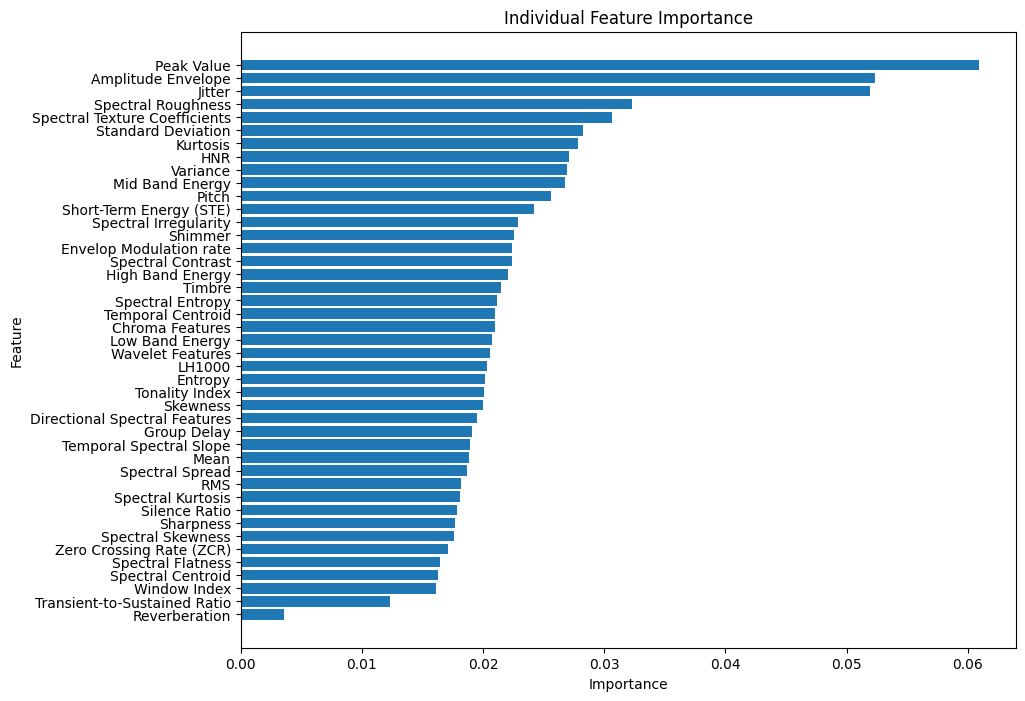

             Feature Group  Importance
0     Time Domain Analysis    0.079082
1        Spectral Features    0.076084
2        Harmonic Features    0.052666
3  Time-Frequency Features    0.039618
4      Perceptual Features    0.021471
6         Derived Features    0.020341
5  Psychoacoustic Features    0.000000


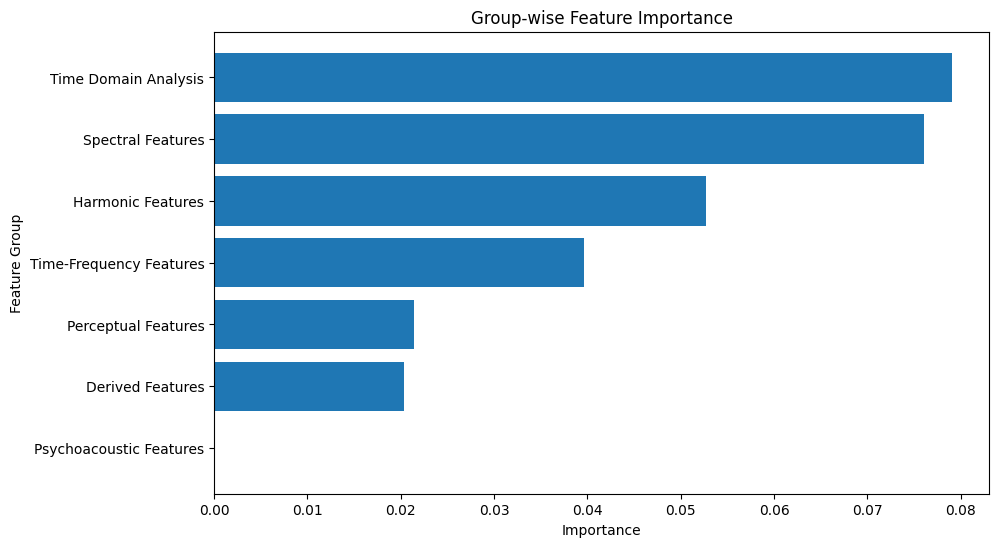

In [82]:
##Analyzing feature importances

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Example: If you have already trained a RandomForestClassifier called rf_model
# Assuming the features are in 'X_train' and target labels are in 'y_train'

# Fit the RF model (if not already trained)
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = clf.feature_importances_

# Create a DataFrame for individual feature importances
individual_importance_df = pd.DataFrame({
    'Feature':features_list3.iloc[:,:-1].columns,
    'Importance': feature_importances
})

# Sort by importance (descending)
individual_importance_df = individual_importance_df.sort_values(by='Importance', ascending=False)

# Display individual feature importances
print(individual_importance_df)

# Plot individual feature importances
plt.figure(figsize=(10, 8))
plt.barh(individual_importance_df['Feature'], individual_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Individual Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Define feature groups (example groups based on your feature categorization)
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR',  'Harmonic Ratio'],
#     'Phonetic/Linguistic Features': ['MFCC', 'Formants', 'PLP-CC'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

# Calculate group-wise feature importance
group_importance = {}
for group, features in feature_groups.items():
    group_importance[group] = individual_importance_df[individual_importance_df['Feature'].isin(features)]['Importance'].sum()

# Convert to DataFrame for easier visualization
group_importance_df = pd.DataFrame({
    'Feature Group': list(group_importance.keys()),
    'Importance': list(group_importance.values())
}).sort_values(by='Importance', ascending=False)

# Display group-wise feature importances
print(group_importance_df)

# Plot group-wise feature importances
plt.figure(figsize=(10, 6))
plt.barh(group_importance_df['Feature Group'], group_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature Group')
plt.title('Group-wise Feature Importance')
plt.gca().invert_yaxis()
plt.show()


In [202]:
# !pip install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Assuming you have your dataset loaded in X and y
# Example split (replace with your actual data):
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Get permutation importance results
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)

# Plot overall feature importance
importance_df = pd.DataFrame({
    'Feature': features_list3.iloc[:,:-1].columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Average Importance Score')
plt.title('Overall Feature Importance - Permutation')
plt.gca().invert_yaxis()
plt.show()

# If you want class-wise feature importance, evaluate predictions per class
classes = clf.classes_
for class_idx, class_name in enumerate(classes):
    # Mask the target to binary: 1 if it's the class, 0 otherwise
    y_binary = (y_test == class_name).astype(int)
    
    # Compute permutation importance for this specific class
    result = permutation_importance(clf, X_test, y_binary, n_repeats=10, random_state=42)
    print(result)
    class_importance_df = pd.DataFrame({
        'Feature': features_list3.iloc[:,:-1].columns,
        'Importance': result.importances_mean
    }).sort_values(by='Importance', ascending=False)

    # Plot the feature importance for this class
    plt.figure(figsize=(12, 8))
    plt.barh(class_importance_df['Feature'], class_importance_df['Importance'], color='lightgreen')
    plt.xlabel('Average Importance Score')
    plt.title(f'Feature Importance for Class: {class_name}')
    plt.gca().invert_yaxis()
    plt.show()


In [189]:
X_train.shape

(5548, 27)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.datasets import make_classification

# Let's assume model, X, y are already defined
# model = RandomForestClassifier()
# model.fit(X, y)

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

# For each class, compute and plot feature importance
for i in range(n_classes):
    plt.figure(figsize=(10, 6))
    
    # Create a binary problem and train a model for this specific class
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100)
    binary_model.fit(X_, binary_y)
    
    importances = binary_model.feature_importances_
    std = np.std([tree.feature_importances_ for tree in binary_model.estimators_], axis=0)
    indices = np.argsort(importances)[::-1]
    
    # Print the feature ranking
    class_label = label_binarizer.classes_[i]
    print(f"Feature ranking for class {class_label}:")
    
    for f in range(X_.shape[1]):
        print(f"{f + 1}. feature {indices[f]} ({importances[indices[f]]})")
    
    # Plot the feature importances of the forest
    plt.title(f"Feature importances for class {class_label}")
    plt.bar(range(X_.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
    plt.xticks(range(X_.shape[1]), indices)
    plt.xlim([-1, X_.shape[1]])
    plt.show()


NameError: name 'X_' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff', 'spectral contrast', 'HNR', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5'] + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
# feature_names = feature_names[:-16]

# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] 


In [ ]:
len(feature_names)

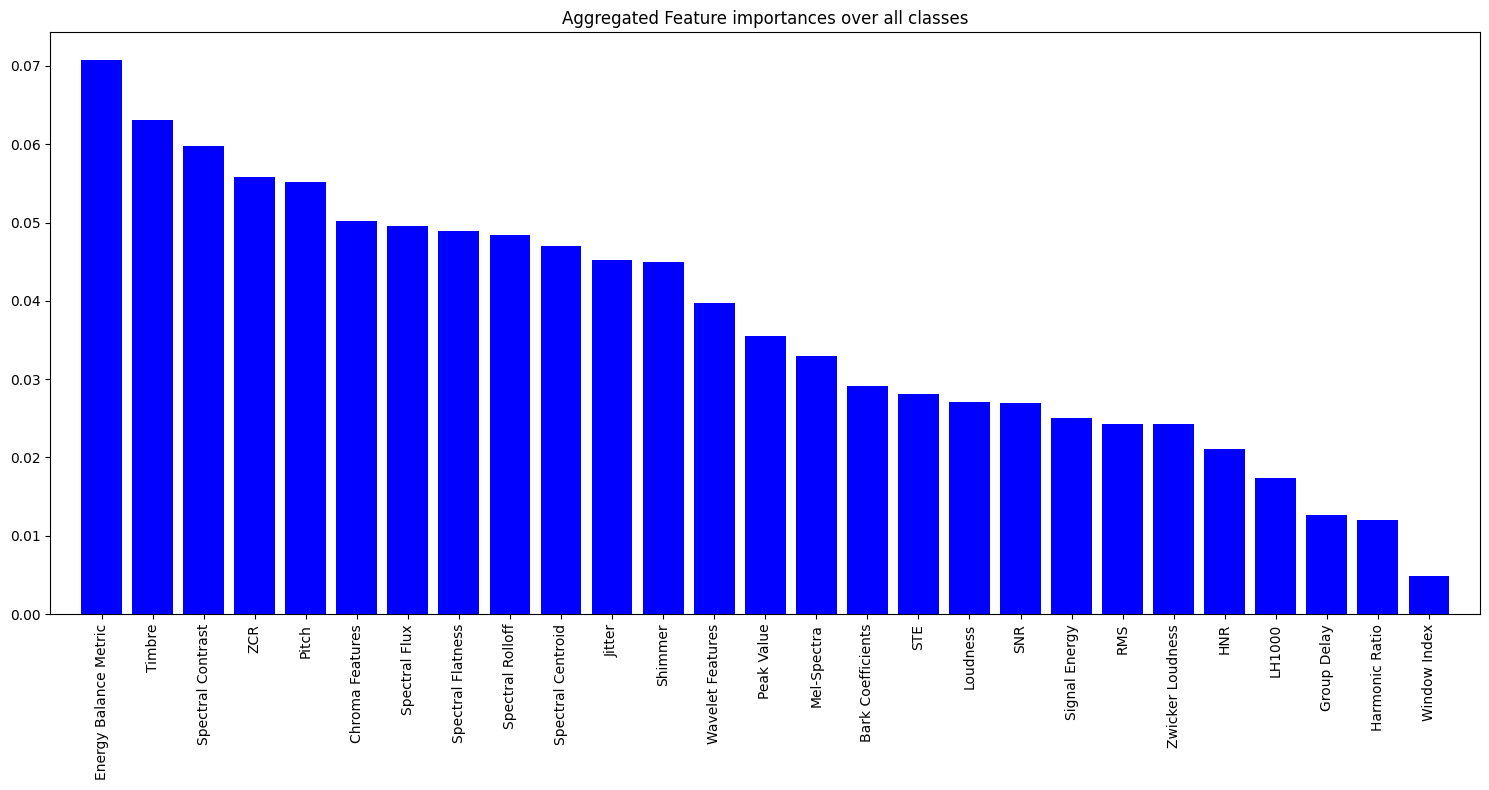

Ranking of features based on aggregated importance:
1. Energy Balance Metric (0.07074846612156614)
2. Timbre (0.06311571736013233)
3. Spectral Contrast (0.059745673832844966)
4. ZCR (0.05587046912341517)
5. Pitch (0.055124830455671806)
6. Chroma Features (0.05017080826506987)
7. Spectral Flux (0.04953752580978519)
8. Spectral Flatness (0.04890485392944869)
9. Spectral Rolloff (0.04840630703207073)
10. Spectral Centroid (0.04697329726467345)
11. Jitter (0.04521658026035875)
12. Shimmer (0.04498446411235076)
13. Wavelet Features (0.03974220290603531)
14. Peak Value (0.035551044903059804)
15. Mel-Spectra (0.032991581439611714)
16. Bark Coefficients (0.029160555207889172)
17. STE (0.028154616948325373)
18. Loudness (0.027127255955117068)
19. SNR (0.02689192749838891)
20. Signal Energy (0.024999659128832296)
21. RMS (0.02426822641588105)
22. Zwicker Loudness (0.024250528293516663)
23. HNR (0.02111296980126726)
24. LH1000 (0.017394599091983484)
25. Group Delay (0.012672749678521328)
26. Harm

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer

# Updated Feature names
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] 
# Let's assume model, X, y are already defined
# model = RandomForestClassifier()
# model.fit(X, y)


X = X
y = y

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

feature_names= features_list3.iloc[:,:-1].columns

# Initialize a zero array to hold the aggregated feature importances
aggregate_importances = np.zeros(X.shape[1])

# For each class, compute feature importance
for i in range(n_classes):
    
    # Create a binary problem and train a model for this specific class
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100)
    binary_model.fit(X, binary_y)
    
    # Aggregate feature importances
    aggregate_importances += binary_model.feature_importances_

# Normalize the aggregated feature importances
aggregate_importances /= n_classes

# Sort the features based on the aggregated importance
sorted_indices = np.argsort(aggregate_importances)[::-1]

# Print and Plot the aggregated feature importances
plt.figure(figsize=(15, 8))
plt.title("Aggregated Feature importances over all classes")
plt.bar(range(X.shape[1]), aggregate_importances[sorted_indices], color="b", align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in sorted_indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()  # To ensure the x-axis labels are visible
plt.show()

# Print the ranking of features
print("Ranking of features based on aggregated importance:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[sorted_indices[f]]} ({aggregate_importances[sorted_indices[f]]})")


In [76]:
len(feature_names), X.shape

(36, (70963, 16))

In [133]:
# # feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] 
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)]+['HNR', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5']  + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
# feature_names = feature_names[:-26]


# # Normalize the aggregated feature importances
# aggregate_importances /= n_classes

# # Sort the features based on the aggregated importance
# sorted_indices = np.argsort(aggregate_importances)[::-1]
# print(sorted_indices)

# # Print and Plot the aggregated feature importances
# plt.figure(figsize=(15, 8))
# # plt.title("Aggregated Feature importances over all classes")
# plt.bar(range(X.shape[1]), aggregate_importances[sorted_indices], align="center")
# plt.xticks(range(X.shape[1]), [feature_names[i] for i in sorted_indices], rotation=90, fontsize=14)
# plt.xlim([-1, X.shape[1]])
# plt.ylabel('Gini Importance', fontsize=14)
# plt.tight_layout()  # To ensure the x-axis labels are visible
# plt.show()


# # Print the ranking of features
# print("Ranking of features based on aggregated importance:")
# for f in range(X.shape[1]):
#     print(f"{f + 1}. {feature_names[sorted_indices[f]]} ({aggregate_importances[sorted_indices[f]]})")


[ 1 15 10 13 12  3  9  2  0 14  8 11  7  6  5  4]


IndexError: tuple index out of range

<Figure size 1500x800 with 0 Axes>

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer

# Updated Feature names
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)]+['HNR', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5']  + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
# feature_names = feature_names[:-26]

# Let's assume model, X, y are already defined
# model = RandomForestClassifier()
# model.fit(X, y)
feature_names= features_list3.iloc[:,:-1].columns

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

# For each class, compute and plot feature importance
class_importances = {}
for i in range(n_classes):
    
    # Create a binary problem and train a model for this specific class
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100)
    binary_model.fit(X, binary_y)
    
    importances = binary_model.feature_importances_
    std = np.std([tree.feature_importances_ for tree in binary_model.estimators_], axis=0)
    sorted_indices = np.argsort(importances)[::-1]
    
    # Print the feature ranking
    class_label = label_binarizer.classes_[i]
    print(f"Feature ranking for class {class_label}:")

    dict_ = {}
    for f in range(X.shape[1]):
        print(f"{f + 1}. {feature_names[sorted_indices[f]]} ({importances[sorted_indices[f]]})")
        dict_[feature_names[sorted_indices[f]]] = importances[sorted_indices[f]]

    class_importances[i] = dict_
    # # Plot the feature importances of the forest
    # plt.figure(figsize=(15, 8))
    # plt.title(f"Feature importances for class {class_label}")
    # plt.bar(range(X.shape[1]), importances[sorted_indices], color="r", yerr=std[sorted_indices], align="center")
    # plt.xticks(range(X.shape[1]), [feature_names[i] for i in sorted_indices], rotation=90)
    # plt.xlim([-1, X.shape[1]])
    # plt.tight_layout()  # To ensure the x-axis labels are visible
    # plt.show()


Feature ranking for class 0:
1. Energy Balance Metric (0.05684499667978183)
2. Timbre (0.05663820069820782)
3. LH1000 (0.05350370925008843)
4. Wavelet Features (0.04970216310501491)
5. Spectral Rolloff (0.04691147636268788)
6. Jitter (0.045942436240812935)
7. Shimmer (0.04563762411798442)
8. Bark Coefficients (0.04497123270892847)
9. Spectral Contrast (0.042890675022343894)
10. Spectral Centroid (0.042618243067137816)
11. Peak Value (0.04238087254435809)
12. Chroma Features (0.04189235096951591)
13. ZCR (0.035555140855687076)
14. Mel-Spectra (0.0354752701110304)
15. Signal Energy (0.03327325477850016)
16. Spectral Flatness (0.032999747821439065)
17. STE (0.032624418892376356)
18. SNR (0.030522655041680516)
19. Spectral Flux (0.02972584587252649)
20. Pitch (0.028404867993491484)
21. HNR (0.02817359998711376)
22. RMS (0.027752506306737545)
23. Zwicker Loudness (0.025802850456603677)
24. Group Delay (0.02466377755061286)
25. Harmonic Ratio (0.023663140395905752)
26. Loudness (0.0234337623

In [79]:
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
len(feature_names)

42

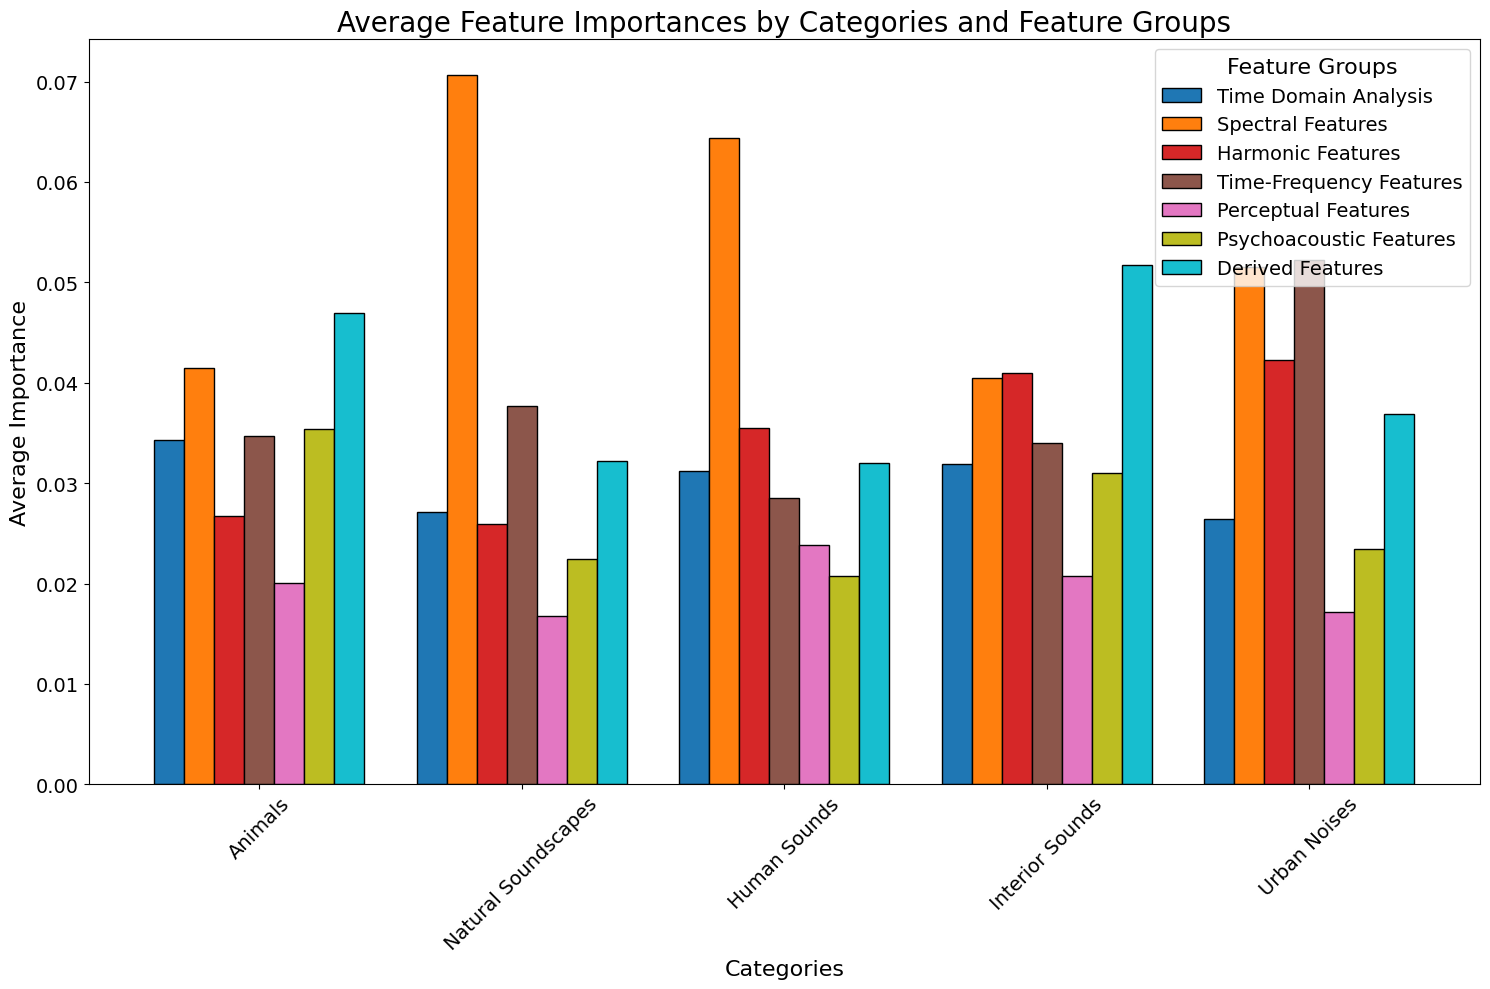

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature groups
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

# Example data structure for feature importance rankings (replace with actual values)
categories = ["Animals", "Natural Soundscapes", "Human Sounds", "Interior Sounds", "Urban Noises"]

# # Aggregate data for all classes (e.g., from your provided feature rankings)
# # Create a dictionary of feature importances for each class (fill with your actual values)
# class_importances = {
#     0: {"RMS": 0.026, "ZCR": 0.04, "Peak Value": 0.046, "Spectral Centroid": 0.04, "Timbre": 0.069, ...},  # Class 0 importances
#     1: {...},  # Class 1 importances
#     # Add all other classes
# }

# Aggregate feature importances for groups
group_importances = {category: {group: 0 for group in feature_groups.keys()} for category in categories}

for category_idx, category in enumerate(categories):
    for group, features in feature_groups.items():
        for feature in features:
            if feature in class_importances[category_idx]:  # Only aggregate existing features
                group_importances[category][group] += class_importances[category_idx][feature]
        # Average the importance for each group
        group_importances[category][group] /= len(features)

# Convert to DataFrame for easier manipulation
df_group_importances = pd.DataFrame(group_importances)

# Transpose to have categories on the x-axis
df_group_importances = df_group_importances.T

# Plot the results
df_group_importances.plot(
    kind='bar',
    figsize=(15, 10),
    width=0.8,
    edgecolor='black',
    colormap='tab10'
)

# Formatting
plt.title('Average Feature Importances by Categories and Feature Groups', fontsize=20)
plt.xlabel('Categories', fontsize=16)
plt.ylabel('Average Importance', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc="upper right", title="Feature Groups", title_fontsize=16)
plt.tight_layout()
plt.show()


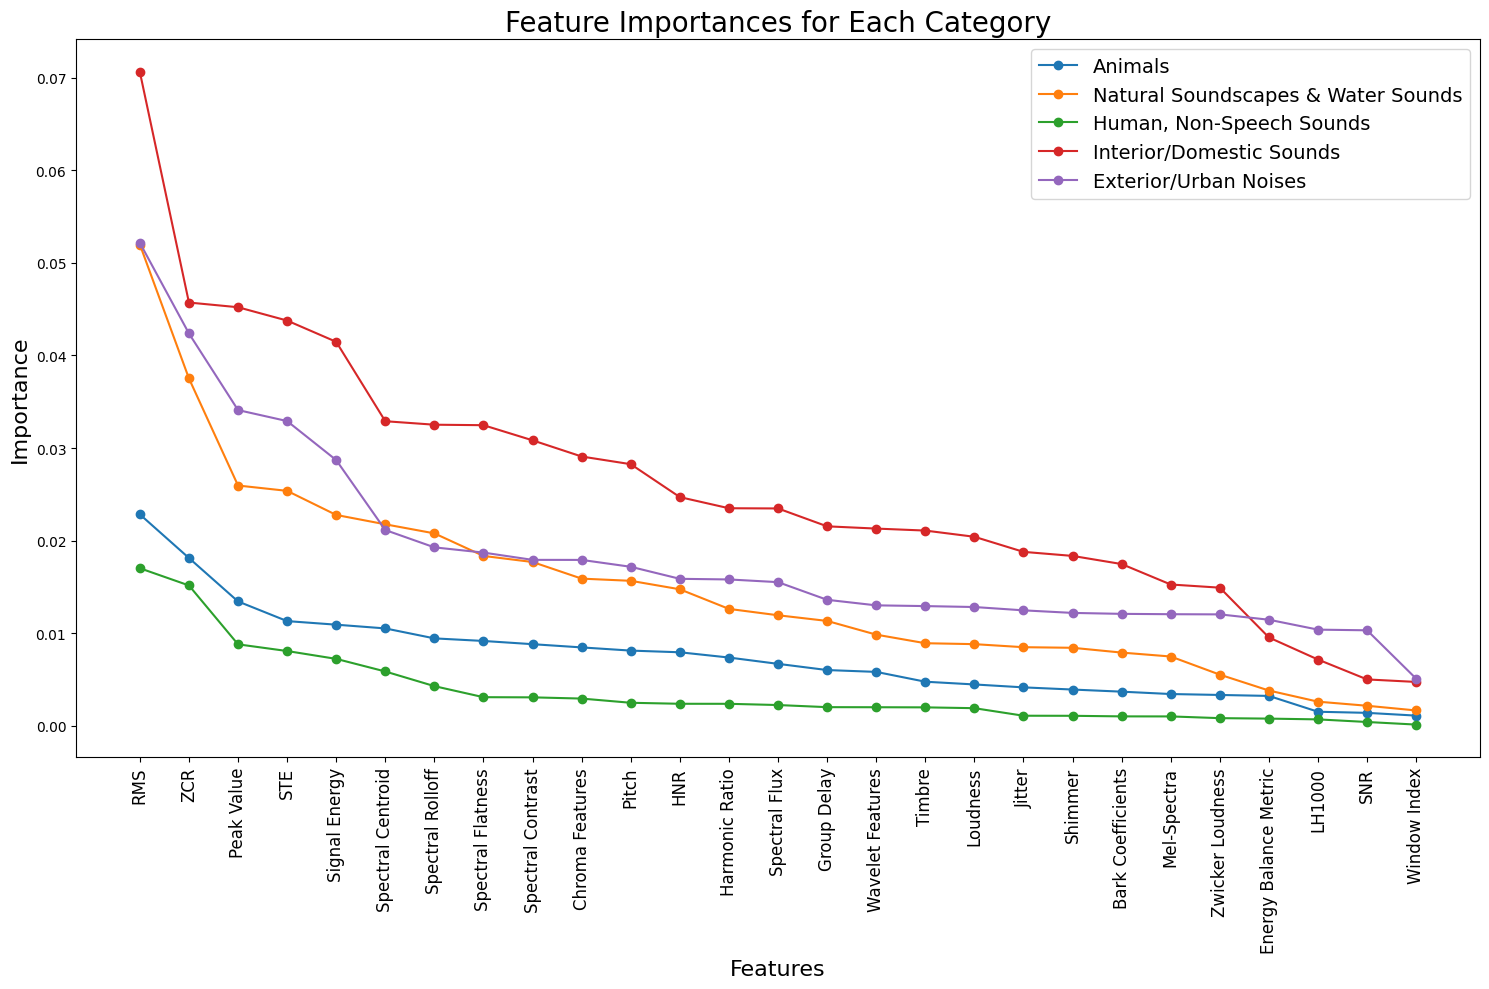

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import matplotlib.pyplot as plt

# Assume X, y, and feature_names are already defined
# Define your category-to-classes mapping
categories = {
    "Animals": [0, 45, 41, 22, 25, 48, 43, 6, 35, 37],
    "Natural Soundscapes & Water Sounds": [28, 40, 26, 16, 14, 46, 15, 13, 39, 19],
    "Human, Non-Speech Sounds": [34, 42, 7, 33, 36, 20, 30, 31, 47, 27],
    "Interior/Domestic Sounds": [4, 11, 18, 5, 23, 44, 9, 17, 38, 3],
    "Exterior/Urban Noises": [1, 10, 12, 21, 32, 24, 29, 2, 8, 49],
}

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

# Store feature importances for each class
class_feature_importances = {}

for i in range(n_classes):
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100, random_state=42)
    binary_model.fit(X, binary_y)
    
    class_feature_importances[i] = binary_model.feature_importances_

# Aggregate feature importances for each category
category_feature_importances = {category: np.zeros(X.shape[1]) for category in categories}

for category, class_indices in categories.items():
    for class_idx in class_indices:
        if class_idx in class_feature_importances:
            category_feature_importances[category] += class_feature_importances[class_idx]
    # Average by the number of classes in the category
    category_feature_importances[category] /= len(class_indices)

# Plot feature importances for each category
plt.figure(figsize=(15, 10))

for category, importances in category_feature_importances.items():
    sorted_indices = np.argsort(importances)[::-1]
    
    plt.plot(
        range(len(importances)),
        importances[sorted_indices],
        label=category,
        marker="o"
    )

# Formatting
plt.title("Feature Importances for Each Category", fontsize=20)
plt.xlabel("Features", fontsize=16)
plt.ylabel("Importance", fontsize=16)
plt.xticks(range(X.shape[1]), feature_names, rotation=90, fontsize=12)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


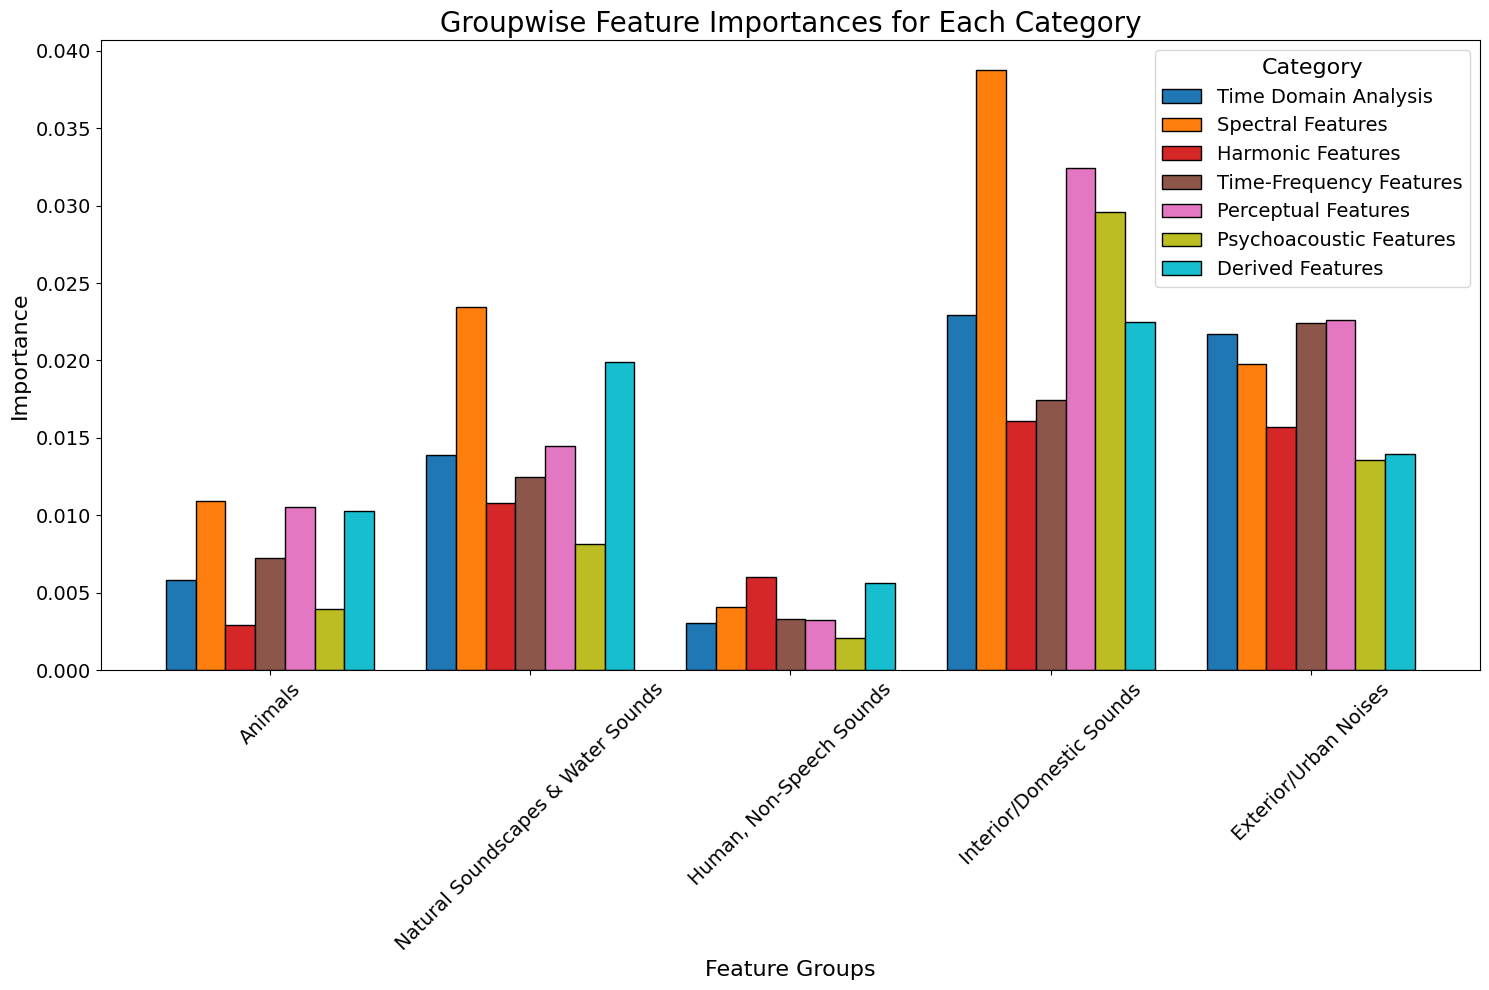

In [126]:
# Feature group mapping
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

# Simulate feature names and their mapping to groups (replace with actual feature names)
all_features = sum(feature_groups.values(), [])  # Flatten the feature group list
feature_indices = {feature: i for i, feature in enumerate(all_features)}  # Assign indices

# Ensure your feature importances align with `all_features`
# feature_importances_matrix = np.random.rand(len(categories), len(all_features))  # Replace with actual importances
feature_importances_matrix = category_feature_importances
# Aggregate feature importances by group for each category
groupwise_importances = {category: {} for category in categories}

for category, importances in category_feature_importances.items():
    for group, features in feature_groups.items():
        group_indices = [feature_indices[feature] for feature in features if feature in feature_indices]
        group_importance = importances[group_indices].mean() if group_indices else 0
        groupwise_importances[category][group] = group_importance

# Convert to DataFrame for easier plotting
df_groupwise_importances = pd.DataFrame(groupwise_importances)

# Plot groupwise feature importances
df_groupwise_importances.T.plot(
    kind="bar",
    figsize=(15, 10),
    width=0.8,
    edgecolor="black",
    colormap="tab10",
)

# Formatting
plt.title("Groupwise Feature Importances for Each Category", fontsize=20)
plt.ylabel("Importance", fontsize=16)
plt.xlabel("Feature Groups", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc="upper right", title="Category", title_fontsize=16)
plt.tight_layout()
plt.show()


In [117]:
# # Rewriting the corrected code for plotting groupwise feature importances

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Define feature groups
# feature_groups = {
#     'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
#     'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
#     'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
#     'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
#     'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
#     'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
#     'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
# }

# # Simulate feature names and feature importances
# all_features = sum(feature_groups.values(), [])  # Flatten feature group list
# feature_indices = {feature: i for i, feature in enumerate(all_features)}  # Map feature to index
# n_categories = 5
# n_features = len(all_features)

# # Simulate feature importances for categories (replace with actual values)
# category_names = ["Animals", "Natural Soundscapes", "Human Sounds", "Interior Sounds", "Urban Noises"]
# feature_importances_matrix = category_feature_importances

# # Aggregate feature importances by group for each category
# groupwise_importances = {category: {} for category in category_names}

# for cat_idx, category in enumerate(category_names):
#     for group, features in feature_groups.items():
#         group_indices = [feature_indices[feature] for feature in features if feature in feature_indices]
#         group_importance = feature_importances_matrix[cat_idx, group_indices].sum() if group_indices else 0
#         groupwise_importances[category][group] = group_importance

# # Convert to DataFrame for easier plotting
# df_groupwise_importances = pd.DataFrame(groupwise_importances)

# # Transpose the DataFrame to have categories on x-axis
# df_groupwise_importances = df_groupwise_importances.T

# # Plot with categories on x-axis and feature groups as legends
# df_groupwise_importances.plot(
#     kind="bar",
#     figsize=(15, 10),
#     width=0.8,
#     edgecolor="black",
#     colormap="tab10"
# )

# # Formatting
# plt.title("Feature Importances by Categories and Feature Groups", fontsize=20)
# plt.ylabel("Importance", fontsize=16)
# plt.xlabel("Categories", fontsize=16)
# plt.xticks(rotation=45, fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(
#     fontsize=14,
#     loc="upper right",
#     title="Feature Groups",
#     title_fontsize=16
# )
# plt.tight_layout()
# plt.show()



TypeError: unhashable type: 'list'

In [124]:
feature_importances_matrix

{'Animals': array([0.00669136, 0.01051791, 0.00476306, 0.00333263, 0.00368821,
        0.0109215 , 0.00846682, 0.01812302, 0.00794106, 0.00916323,
        0.00582354, 0.00151984, 0.00139999, 0.00944242, 0.00343289,
        0.00881518, 0.0228324 , 0.00391743, 0.0073735 , 0.00812273,
        0.00446729, 0.00415254, 0.00322846, 0.01343182, 0.01130767,
        0.00602187, 0.00110162]),
 'Natural Soundscapes & Water Sounds': array([0.01565865, 0.02175983, 0.01193808, 0.00881934, 0.01132738,
        0.01834453, 0.02277026, 0.01262531, 0.0259478 , 0.03751497,
        0.02078121, 0.00891926, 0.00260747, 0.01768878, 0.0038101 ,
        0.01589373, 0.02537255, 0.00790808, 0.01474331, 0.00984627,
        0.0074845 , 0.0084902 , 0.00842617, 0.05197256, 0.00216589,
        0.0055254 , 0.00165837]),
 'Human, Non-Speech Sounds': array([0.00237637, 0.00586715, 0.00294317, 0.0020064 , 0.00199308,
        0.00108973, 0.00108172, 0.00224425, 0.00722889, 0.00879926,
        0.01701615, 0.00041308, 0.00069

In [83]:
X.shape

(70963, 16)

In [94]:
feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']

feature_values = [5.36318398e+01, 3.98404208e-01, 2.11871937e-02, 2.91809082e-01, 8.72630920e+02, 9.06393677e+02, 9.32497314e+02, 9.43086182e+02, 1.06946826e+03, 1.06029837e+04, 4.81161295e+03, 3.12744707e-01, 1.57412609e+04, 8.36915017e+00, 7.39511880e+00, 9.28489404e+00, 1.20502612e+01, 1.60105151e+01, 1.84078397e+01, 2.36899452e+01, 1.04202425e+00, -6.68151489e+02, -2.88678417e+01, -1.21740026e+01, 1.53598509e+01, -6.51576805e+00, 1.13960352e+01, -1.06159420e+01, -2.49587834e-01, 1.00122416e+00, 3.78168797e+00, 1.35483757e-01, -2.86324000e+00, -1.93524742e+00, 1.71072376e+00, 3.56045127e+00, -2.79734135e+00, -6.33295953e-01, 3.65585357e-01, -3.98711562e-01, 6.74959004e-01, 1.84366432e+03]

feature_dict = {name: value for name, value in zip(feature_names, feature_values)}

print(feature_dict)


{'energy': 53.6318398, 'ZCR': 0.398404208, 'RMS': 0.0211871937, 'peak value': 0.291809082, 'formant1': 872.63092, 'formant2': 906.393677, 'formant3': 932.497314, 'formant4': 943.086182, 'formant5': 1069.46826, 'spectral centroid': 10602.9837, 'spectral BW': 4811.61295, 'spectral flatness': 0.312744707, 'spectral rolloff': 15741.2609, 'spectral contrast1': 8.36915017, 'spectral contrast2': 7.3951188, 'spectral contrast3': 9.28489404, 'spectral contrast4': 12.0502612, 'spectral contrast5': 16.0105151, 'spectral contrast6': 18.4078397, 'spectral contrast7': 23.6899452, 'HNR': 1.04202425, 'MFCC1': -668.151489, 'MFCC2': -28.8678417, 'MFCC3': -12.1740026, 'MFCC4': 15.3598509, 'MFCC5': -6.51576805, 'MFCC6': 11.3960352, 'MFCC7': -10.615942, 'MFCC8': -0.249587834, 'MFCC9': 1.00122416, 'MFCC10': 3.78168797, 'MFCC11': 0.135483757, 'MFCC12': -2.86324, 'MFCC13': -1.93524742, 'MFCC14': 1.71072376, 'MFCC15': 3.56045127, 'MFCC16': -2.79734135, 'MFCC17': -0.633295953, 'MFCC18': 0.365585357, 'MFCC19': -

In [95]:
import tensorflow

SyntaxError: invalid syntax (pywrap_tensorflow_internal.py, line 114)

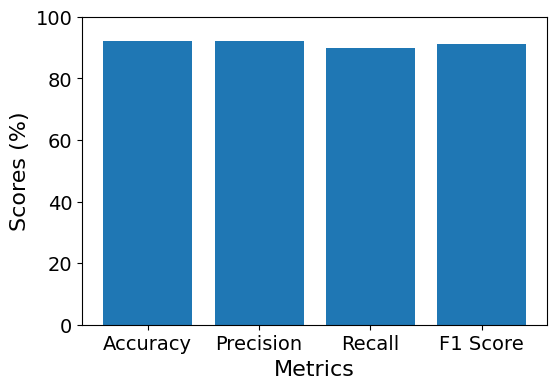

In [137]:
import matplotlib.pyplot as plt

# Data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
# values = [88.76, 89, 86, 87]
values = [92.23, 92, 90, 91]

# Creating the bar plot
plt.figure(figsize=(6, 4))
plt.bar(metrics, values)

plt.xlabel('Metrics', fontsize=16)
plt.ylabel('Scores (%)', fontsize=16)
# plt.title('Model Performance Metrics')
plt.ylim(0, 100)  # Setting the limit for y-axis to make the graph easier to read
plt.grid(axis='y', linestyle='')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Display the plot
plt.show()

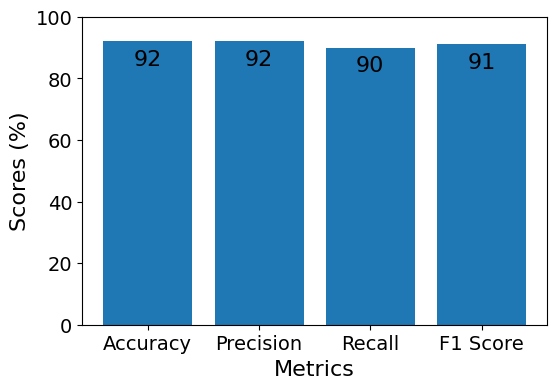

In [11]:
import matplotlib.pyplot as plt

# Data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [92, 92, 90, 91]

# Creating the bar plot
plt.figure(figsize=(6, 4))
bar_positions = range(len(metrics))
bars = plt.bar(bar_positions, values)

# Annotate the bar values
for i, v in enumerate(values):
    plt.text(i, v - 9, str(v), color='black', fontsize=16, ha='center', va='bottom')

plt.xlabel('Metrics', fontsize=16)
plt.ylabel('Scores (%)', fontsize=16)
plt.ylim(0, 100)  # Setting the limit for y-axis to make the graph easier to read
plt.grid(axis='y', linestyle='')
plt.xticks(bar_positions, metrics, fontsize=14)
plt.yticks(fontsize=14)

# Display the plot
plt.show()

In [2]:
X_train

NameError: name 'X_train' is not defined